# Big Data Pipeline: U.S. Border Crossing Analysis with Apache Spark and MongoDB

### Team Contributions

The project was completed through a structured division of responsibilities, ensuring both efficiency and consistency across all stages of the pipeline.

- **Muhamed Aniss Lotfy** was responsible for data preprocessing and initial exploration (Sections 1–3), as well as the analysis of seasonal patterns in border crossings (Section 9.2).

- **Jie Xu** focused on data transformation and Spark-based processing (Sections 4–5), and conducted the analysis of external factors, particularly the impact of COVID-19 on border crossings (Section 9.3).

- **Mu Zhao** handled database integration and querying (Sections 6–7), and performed advanced analysis on port growth and decline trends (Section 9.4).

- **Weiwei Zhang** was responsible for overall system design and integration, performance comparison and optimization (Section 8), long-term structural analysis (Section 9.1), and the implementation of bonus tasks. Additionally, the project lead ensured consistency across all sections and coordinated the final structure of the report.

## 1. Environment Setup

This section initializes the required environment, including Apache Spark, MongoDB connection, and necessary Python libraries.

In [1]:
# Initialize Spark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = SparkSession.builder \
    .appName("BorderCrossingAnalysis") \
    .getOrCreate()

print("Spark is working!")

Spark is working!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


## 2. Data Loading and Initial Inspection

In this section, we load the dataset and perform initial inspection to understand its structure, size, and key attributes.

In [3]:
df = spark.read.csv("Border_Crossing_Entry_Data.csv", header=True, inferSchema=True)

print("Data loaded successfully!")

Data loaded successfully!


In [4]:
# Preview the data
df.show(5)

+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|  Port Name|    State|Port Code|          Border|    Date|Measure|Value|Latitude|Longitude|               Point|
+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|    Hidalgo|    Texas|     2305|US-Mexico Border|Jan 2026|  Buses|  640|  26.095|  -98.271|POINT (-98.271092...|
|Brownsville|    Texas|     2301|US-Mexico Border|Jan 2026|  Buses|  264|  25.952|  -97.401|POINT (-97.40067 ...|
|    Warroad|Minnesota|     3423|US-Canada Border|Dec 2025|  Buses|    9|  48.999|  -95.377|POINT (-95.376555...|
|      Alcan|   Alaska|     3104|US-Canada Border|Nov 2025| Trucks|  547|  62.615| -141.001|POINT (-141.00144...|
|     Laredo|    Texas|     2304|US-Mexico Border|Jul 2025|  Buses| 2546|    27.5|  -99.507|POINT (-99.507412...|
+-----------+---------+---------+----------------+--------+-------+-----+--------+------

In [5]:
# Dataset structure
df.printSchema()

root
 |-- Port Name: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Port Code: integer (nullable = true)
 |-- Border: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Measure: string (nullable = true)
 |-- Value: integer (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Point: string (nullable = true)



In [6]:
rows = df.count()
cols = len(df.columns)

print(f"Total rows: {rows}")
print(f"Total columns: {cols}")

Total rows: 273391
Total columns: 10


In [7]:
print("Column names:")
for col_name in df.columns:
    print(col_name)

Column names:
Port Name
State
Port Code
Border
Date
Measure
Value
Latitude
Longitude
Point


In [8]:
# Statistical summary
df.describe().show()

+-------+---------+----------+------------------+----------------+--------+--------------+------------------+------------------+------------------+--------------------+
|summary|Port Name|     State|         Port Code|          Border|    Date|       Measure|             Value|          Latitude|         Longitude|               Point|
+-------+---------+----------+------------------+----------------+--------+--------------+------------------+------------------+------------------+--------------------+
|  count|   273391|    273387|            273391|          273391|  273391|        273391|            273391|            273387|            273387|              273387|
|   mean|     NULL|      NULL|  2447.97364946176|            NULL|    NULL|          NULL| 41979.96001697203|43.909012114695585|-99.81721089518044|                NULL|
| stddev|     NULL|      NULL|1199.7471110625095|            NULL|    NULL|          NULL|180977.99503700226| 8.183531831499531| 18.23658657198981|        

In [9]:
from pyspark.sql.functions import col, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
]).show()

+---------+-----+---------+------+----+-------+-----+--------+---------+-----+
|Port Name|State|Port Code|Border|Date|Measure|Value|Latitude|Longitude|Point|
+---------+-----+---------+------+----+-------+-----+--------+---------+-----+
|        0|    4|        0|     0|   0|      0|    0|       4|        4|    4|
+---------+-----+---------+------+----+-------+-----+--------+---------+-----+



## 3. Data Cleaning and Feature Engineering

This section prepares the dataset for analysis by handling missing values, selecting relevant columns, and extracting useful features such as year and month from the date field.

In [10]:
# Select relevant columns
df_clean = df.select(
    "Port Name",
    "State",
    "Border",
    "Date",
    "Measure",
    "Value"
)

df_clean.select("Date").show(5, False)

+--------+
|Date    |
+--------+
|Jan 2026|
|Jan 2026|
|Dec 2025|
|Nov 2025|
|Jul 2025|
+--------+
only showing top 5 rows


In [11]:
# Handle missing values
df_clean = df_clean.dropna(subset=["Value"])

In [12]:


df_clean = df_clean.withColumn(
    "Date",
    F.to_date(
        F.concat(F.lit("01 "), F.trim(F.col("Date"))),
        "dd MMM yyyy"
    )
)

df_clean.select("Date").show(5, False)

+----------+
|Date      |
+----------+
|2026-01-01|
|2026-01-01|
|2025-12-01|
|2025-11-01|
|2025-07-01|
+----------+
only showing top 5 rows


In [13]:
df_clean = df_clean.withColumn("Year", F.year(F.col("Date")))
df_clean = df_clean.withColumn("Month", F.month(F.col("Date")))

df_clean.select("Date", "Year", "Month").show(5)

+----------+----+-----+
|      Date|Year|Month|
+----------+----+-----+
|2026-01-01|2026|    1|
|2026-01-01|2026|    1|
|2025-12-01|2025|   12|
|2025-11-01|2025|   11|
|2025-07-01|2025|    7|
+----------+----+-----+
only showing top 5 rows


In [14]:
# Preview cleaned data
df_clean.show(10)

+--------------------+---------+----------------+----------+--------------------+-----+----+-----+
|           Port Name|    State|          Border|      Date|             Measure|Value|Year|Month|
+--------------------+---------+----------------+----------+--------------------+-----+----+-----+
|             Hidalgo|    Texas|US-Mexico Border|2026-01-01|               Buses|  640|2026|    1|
|         Brownsville|    Texas|US-Mexico Border|2026-01-01|               Buses|  264|2026|    1|
|             Warroad|Minnesota|US-Canada Border|2025-12-01|               Buses|    9|2025|   12|
|               Alcan|   Alaska|US-Canada Border|2025-11-01|              Trucks|  547|2025|   11|
|              Laredo|    Texas|US-Mexico Border|2025-07-01|               Buses| 2546|2025|    7|
|                Roma|    Texas|US-Mexico Border|2025-07-01|               Buses|   67|2025|    7|
|Chief Mountain Mt...|     NULL|US-Canada Border|2025-07-01|   Personal Vehicles| 6082|2025|    7|
|Chief Mou

## 4. MongoDB Storage and Schema Design

The cleaned dataset is stored in MongoDB as a collection of documents.  
Each document represents one border crossing record.

The main attributes include:

- Port Name
- State
- Border
- Date
- Measure
- Value
- MongoDB Sharding Demonstration

MongoDB is suitable because it supports flexible document-based storage, allowing efficient querying and aggregation.

Indexes are created on key fields such as Border, Measure, and Date to improve query performance.

Although the current dataset size is moderate, sharding was demonstrated to show how the MongoDB layer could scale for larger cross-border datasets and distributed query workloads.

In [15]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27120/")
db = client["crossborder_db"]
collection = db["crossings"]

print("Connected to sharded MongoDB cluster through mongos")

Connected to sharded MongoDB cluster through mongos


In [16]:
import pandas as pd
import numpy as np
import datetime
import time

# Start timing
start_time = time.time()

# Convert Spark DataFrame to Pandas
mongo_df = df.toPandas().copy()

# Clean records for MongoDB
records = []
for row in mongo_df.to_dict("records"):
    clean_row = {}
    for k, v in row.items():
        if isinstance(v, datetime.date):
            clean_row[k] = str(v)
        elif isinstance(v, np.integer):
            clean_row[k] = int(v)
        elif isinstance(v, np.floating):
            clean_row[k] = float(v)
        elif pd.isna(v):
            clean_row[k] = None
        else:
            clean_row[k] = v
    records.append(clean_row)

print(f"Prepared {len(records)} records for MongoDB insertion.")

# Clear old data
collection.delete_many({})
print("Old documents deleted.")

# Insert in batches
batch_size = 10000
for i in range(0, len(records), batch_size):
    batch = records[i:i + batch_size]
    collection.insert_many(batch)
    print(f"Inserted {i + len(batch)} / {len(records)}")

# End timing
end_time = time.time()
total_time = round(end_time - start_time, 2)

print("Inserted documents:", collection.count_documents({}))
print("Total insertion time:", total_time, "seconds")

Prepared 273391 records for MongoDB insertion.
Old documents deleted.
Inserted 10000 / 273391
Inserted 20000 / 273391
Inserted 30000 / 273391
Inserted 40000 / 273391
Inserted 50000 / 273391
Inserted 60000 / 273391
Inserted 70000 / 273391
Inserted 80000 / 273391
Inserted 90000 / 273391
Inserted 100000 / 273391
Inserted 110000 / 273391
Inserted 120000 / 273391
Inserted 130000 / 273391
Inserted 140000 / 273391
Inserted 150000 / 273391
Inserted 160000 / 273391
Inserted 170000 / 273391
Inserted 180000 / 273391
Inserted 190000 / 273391
Inserted 200000 / 273391
Inserted 210000 / 273391
Inserted 220000 / 273391
Inserted 230000 / 273391
Inserted 240000 / 273391
Inserted 250000 / 273391
Inserted 260000 / 273391
Inserted 270000 / 273391
Inserted 273391 / 273391
Inserted documents: 273391
Total insertion time: 1956.05 seconds


![Sharding result](image/shards.png)

MongoDB stores the dataset in a document-oriented format and improves query efficiency through indexing on key attributes such as Border, Measure, and Date.

In [17]:
# Query 1
list(collection.find({"Border": "US-Canada Border"}).limit(3))

[{'_id': ObjectId('69e222de8a5f37ddac395e2f'),
  'Port Name': 'Chief Mountain Mt Poe',
  'State': None,
  'Port Code': 3315,
  'Border': 'US-Canada Border',
  'Date': 'Jul 2025',
  'Measure': 'Personal Vehicles',
  'Value': 6082,
  'Latitude': None,
  'Longitude': None,
  'Point': None},
 {'_id': ObjectId('69e222de8a5f37ddac395e30'),
  'Port Name': 'Chief Mountain Mt Poe',
  'State': None,
  'Port Code': 3315,
  'Border': 'US-Canada Border',
  'Date': 'Jun 2025',
  'Measure': 'Personal Vehicle Passengers',
  'Value': 8844,
  'Latitude': None,
  'Longitude': None,
  'Point': None},
 {'_id': ObjectId('69e222de8a5f37ddac395e35'),
  'Port Name': 'Van Buren',
  'State': 'Maine',
  'Port Code': 108,
  'Border': 'US-Canada Border',
  'Date': 'Jan 2025',
  'Measure': 'Trucks',
  'Value': 1166,
  'Latitude': 47.16,
  'Longitude': -67.931,
  'Point': 'POINT (-67.930799 47.159645)'}]

In [18]:
# Query 2
list(collection.find({"Measure": "Personal Vehicles"}).limit(3))

[{'_id': ObjectId('69e222de8a5f37ddac395e2f'),
  'Port Name': 'Chief Mountain Mt Poe',
  'State': None,
  'Port Code': 3315,
  'Border': 'US-Canada Border',
  'Date': 'Jul 2025',
  'Measure': 'Personal Vehicles',
  'Value': 6082,
  'Latitude': None,
  'Longitude': None,
  'Point': None},
 {'_id': ObjectId('69e222de8a5f37ddac395f4b'),
  'Port Name': 'Morgan',
  'State': 'Montana',
  'Port Code': 3319,
  'Border': 'US-Canada Border',
  'Date': 'Oct 2002',
  'Measure': 'Personal Vehicles',
  'Value': 388,
  'Latitude': 49.0,
  'Longitude': -107.832,
  'Point': 'POINT (-107.831819 48.999829)'},
 {'_id': ObjectId('69e222de8a5f37ddac395faf'),
  'Port Name': 'Skagway',
  'State': 'Alaska',
  'Port Code': 3103,
  'Border': 'US-Canada Border',
  'Date': 'Jan 1997',
  'Measure': 'Personal Vehicles',
  'Value': 340,
  'Latitude': 59.63,
  'Longitude': -135.164,
  'Point': 'POINT (-135.164444 59.629722)'}]

In [19]:
# Query 3
list(collection.find({
    "Border": "US-Mexico Border",
    "Measure": "Trucks"
}).limit(3))

[{'_id': ObjectId('69e222de8a5f37ddac395e5a'),
  'Port Name': 'Nogales',
  'State': 'Arizona',
  'Port Code': 2604,
  'Border': 'US-Mexico Border',
  'Date': 'Mar 2021',
  'Measure': 'Trucks',
  'Value': 39374,
  'Latitude': 31.333,
  'Longitude': -110.943,
  'Point': 'POINT (-110.942516 31.332839)'},
 {'_id': ObjectId('69e222de8a5f37ddac395e63'),
  'Port Name': 'Roma',
  'State': 'Texas',
  'Port Code': 2310,
  'Border': 'US-Mexico Border',
  'Date': 'Jan 2020',
  'Measure': 'Trucks',
  'Value': 1499,
  'Latitude': 26.404,
  'Longitude': -99.019,
  'Point': 'POINT (-99.018981 26.403928)'},
 {'_id': ObjectId('69e222de8a5f37ddac395e77'),
  'Port Name': 'Roma',
  'State': 'Texas',
  'Port Code': 2310,
  'Border': 'US-Mexico Border',
  'Date': 'Jan 2018',
  'Measure': 'Trucks',
  'Value': 609,
  'Latitude': 26.404,
  'Longitude': -99.019,
  'Point': 'POINT (-99.018981 26.403928)'}]

In [20]:
print("Inserted:", collection.count_documents({}))

Inserted: 273391


In [21]:
print("Sample records:")
for doc in collection.find().limit(3):
    print(doc)

Sample records:
{'_id': ObjectId('69e222de8a5f37ddac395e29'), 'Port Name': 'Hidalgo', 'State': 'Texas', 'Port Code': 2305, 'Border': 'US-Mexico Border', 'Date': 'Jan 2026', 'Measure': 'Buses', 'Value': 640, 'Latitude': 26.095, 'Longitude': -98.271, 'Point': 'POINT (-98.271092 26.095032)'}
{'_id': ObjectId('69e222de8a5f37ddac395e2a'), 'Port Name': 'Brownsville', 'State': 'Texas', 'Port Code': 2301, 'Border': 'US-Mexico Border', 'Date': 'Jan 2026', 'Measure': 'Buses', 'Value': 264, 'Latitude': 25.952, 'Longitude': -97.401, 'Point': 'POINT (-97.40067 25.95155)'}
{'_id': ObjectId('69e222de8a5f37ddac395e2d'), 'Port Name': 'Laredo', 'State': 'Texas', 'Port Code': 2304, 'Border': 'US-Mexico Border', 'Date': 'Jul 2025', 'Measure': 'Buses', 'Value': 2546, 'Latitude': 27.5, 'Longitude': -99.507, 'Point': 'POINT (-99.507412 27.499561)'}


In [22]:
print("Query test:")
for doc in collection.find({"Border": "US-Canada Border"}).limit(3):
    print(doc)

Query test:
{'_id': ObjectId('69e222de8a5f37ddac395e2f'), 'Port Name': 'Chief Mountain Mt Poe', 'State': None, 'Port Code': 3315, 'Border': 'US-Canada Border', 'Date': 'Jul 2025', 'Measure': 'Personal Vehicles', 'Value': 6082, 'Latitude': None, 'Longitude': None, 'Point': None}
{'_id': ObjectId('69e222de8a5f37ddac395e30'), 'Port Name': 'Chief Mountain Mt Poe', 'State': None, 'Port Code': 3315, 'Border': 'US-Canada Border', 'Date': 'Jun 2025', 'Measure': 'Personal Vehicle Passengers', 'Value': 8844, 'Latitude': None, 'Longitude': None, 'Point': None}
{'_id': ObjectId('69e222de8a5f37ddac395e35'), 'Port Name': 'Van Buren', 'State': 'Maine', 'Port Code': 108, 'Border': 'US-Canada Border', 'Date': 'Jan 2025', 'Measure': 'Trucks', 'Value': 1166, 'Latitude': 47.16, 'Longitude': -67.931, 'Point': 'POINT (-67.930799 47.159645)'}


#MongoDB Sharding Demonstration


## 5. Exploratory Analysis with PySpark DataFrame API

This section performs initial exploratory data analysis using PySpark DataFrame API to understand overall patterns in the dataset.

### 5.1 Total Crossings by Border

This analysis compares the total number of crossings between the U.S.-Canada and U.S.-Mexico borders.

In [23]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CrossBorderEDA") \
    .getOrCreate()

In [24]:
df = spark.read.csv("Border_Crossing_Entry_Data.csv", header=True, inferSchema=True)

In [25]:
df.show(5)
df.printSchema()

+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|  Port Name|    State|Port Code|          Border|    Date|Measure|Value|Latitude|Longitude|               Point|
+-----------+---------+---------+----------------+--------+-------+-----+--------+---------+--------------------+
|    Hidalgo|    Texas|     2305|US-Mexico Border|Jan 2026|  Buses|  640|  26.095|  -98.271|POINT (-98.271092...|
|Brownsville|    Texas|     2301|US-Mexico Border|Jan 2026|  Buses|  264|  25.952|  -97.401|POINT (-97.40067 ...|
|    Warroad|Minnesota|     3423|US-Canada Border|Dec 2025|  Buses|    9|  48.999|  -95.377|POINT (-95.376555...|
|      Alcan|   Alaska|     3104|US-Canada Border|Nov 2025| Trucks|  547|  62.615| -141.001|POINT (-141.00144...|
|     Laredo|    Texas|     2304|US-Mexico Border|Jul 2025|  Buses| 2546|    27.5|  -99.507|POINT (-99.507412...|
+-----------+---------+---------+----------------+--------+-------+-----+--------+------

In [26]:
from pyspark.sql.functions import sum

border_analysis = df.groupBy("Border") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

border_analysis.show()

+----------------+---------------+
|          Border|Total_Crossings|
+----------------+---------------+
|US-Mexico Border|     8596716289|
|US-Canada Border|     2880226960|
+----------------+---------------+



In [27]:
df.createOrReplaceTempView("crossings")

spark.sql("""
SELECT Border, SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY Border
ORDER BY Total_Crossings DESC
""").show()

+----------------+---------------+
|          Border|Total_Crossings|
+----------------+---------------+
|US-Mexico Border|     8596716289|
|US-Canada Border|     2880226960|
+----------------+---------------+



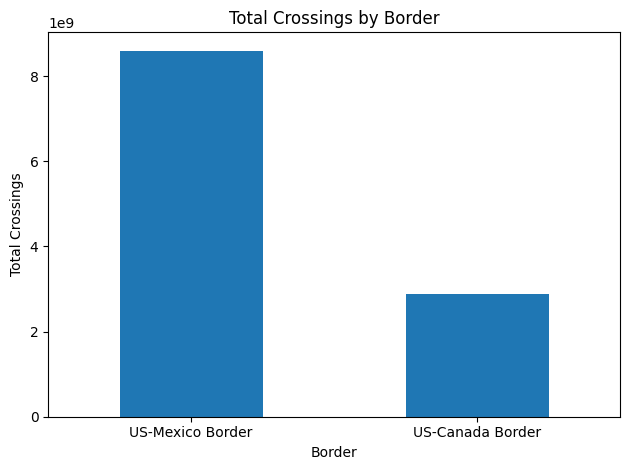

In [28]:
import matplotlib.pyplot as plt

pdf = border_analysis.toPandas()

pdf.plot(kind="bar", x="Border", y="Total_Crossings", legend=False)

plt.title("Total Crossings by Border")
plt.xlabel("Border")
plt.ylabel("Total Crossings")

plt.xticks(rotation=0)   # rotae x-axis labels 90 for better readability

plt.tight_layout()
plt.show()

### 5.2 Total Crossings by Measure

This analysis identifies which transportation measures (e.g., vehicles, pedestrians, trucks) contribute the most to total crossings.

In [29]:
measure_analysis = df.groupBy("Measure") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

measure_analysis.show()

+--------------------+---------------+
|             Measure|Total_Crossings|
+--------------------+---------------+
|Personal Vehicle ...|     6506215972|
|   Personal Vehicles|     3148059957|
|         Pedestrians|     1303898913|
|              Trucks|      340546108|
|      Bus Passengers|      160027594|
|               Buses|        9545006|
|    Train Passengers|        7529303|
|              Trains|        1120396|
+--------------------+---------------+



### 5.3 Total Crossings by Year

This analysis examines how total crossings change over time, revealing long-term trends and potential external impacts.

In [30]:
from pyspark.sql.functions import to_date, year

df = df.withColumn("Date_parsed", to_date("Date", "MMM yyyy"))
df = df.withColumn("Year", year("Date_parsed"))

df.select("Date", "Date_parsed", "Year").show(5, False)

+--------+-----------+----+
|Date    |Date_parsed|Year|
+--------+-----------+----+
|Jan 2026|2026-01-01 |2026|
|Jan 2026|2026-01-01 |2026|
|Dec 2025|2025-12-01 |2025|
|Nov 2025|2025-11-01 |2025|
|Jul 2025|2025-07-01 |2025|
+--------+-----------+----+
only showing top 5 rows


In [31]:
from pyspark.sql.functions import to_date, year, sum

# Extract year from Date column
df = df.withColumn("Date_parsed", to_date("Date", "MMM yyyy"))
df = df.withColumn("Year", year("Date_parsed"))

# Total crossings by year
year_analysis = df.groupBy("Year") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Year")

year_analysis.show()

+----+---------------+
|Year|Total_Crossings|
+----+---------------+
|1996|      424326538|
|1997|      487571047|
|1998|      498367381|
|1999|      526057768|
|2000|      527422164|
|2001|      479842216|
|2002|      462021027|
|2003|      443017400|
|2004|      444305796|
|2005|      436112146|
|2006|      426158914|
|2007|      403615100|
|2008|      386600603|
|2009|      348090864|
|2010|      331717926|
|2011|      319518381|
|2012|      331070167|
|2013|      342606811|
|2014|      349085046|
|2015|      350542766|
+----+---------------+
only showing top 20 rows


In [32]:
spark.sql("""
SELECT YEAR(to_date(Date, 'MMM yyyy')) AS Year,
       SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY YEAR(to_date(Date, 'MMM yyyy'))
ORDER BY Year
""").show()

+----+---------------+
|Year|Total_Crossings|
+----+---------------+
|1996|      424326538|
|1997|      487571047|
|1998|      498367381|
|1999|      526057768|
|2000|      527422164|
|2001|      479842216|
|2002|      462021027|
|2003|      443017400|
|2004|      444305796|
|2005|      436112146|
|2006|      426158914|
|2007|      403615100|
|2008|      386600603|
|2009|      348090864|
|2010|      331717926|
|2011|      319518381|
|2012|      331070167|
|2013|      342606811|
|2014|      349085046|
|2015|      350542766|
+----+---------------+
only showing top 20 rows


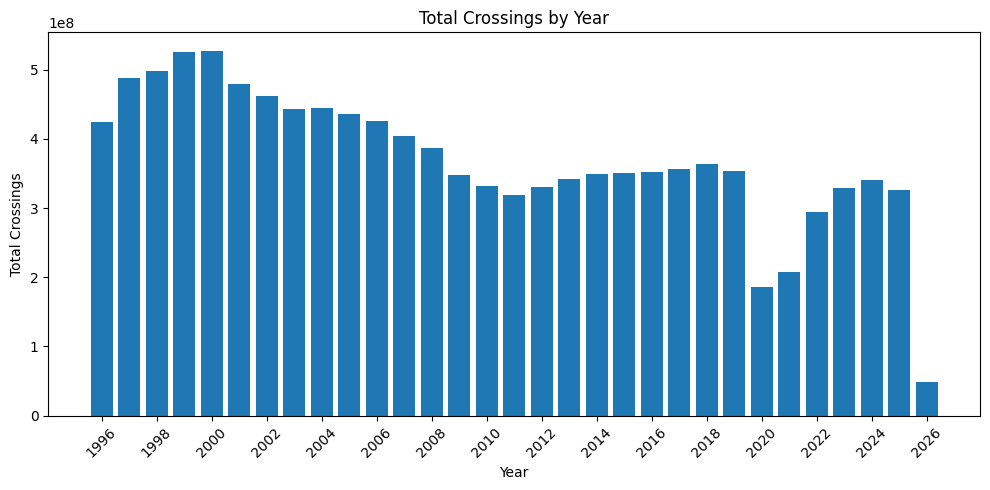

In [33]:
import matplotlib.pyplot as plt

pdf = year_analysis.toPandas()

plt.figure(figsize=(10,5))  

plt.bar(pdf["Year"], pdf["Total_Crossings"])

plt.title("Total Crossings by Year")
plt.xlabel("Year")
plt.ylabel("Total Crossings")

plt.xticks(pdf["Year"][::2], rotation=45) 

plt.tight_layout()
plt.show()

### 5.4 Top Ports by Total Crossings

This analysis identifies the busiest border ports based on total crossing volume.

In [34]:
port_analysis = df.groupBy("Port Name") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Total_Crossings", ascending=False)

port_analysis.show(10)

+--------------------+---------------+
|           Port Name|Total_Crossings|
+--------------------+---------------+
|          San Ysidro|     1449798032|
|             El Paso|     1308744295|
|              Laredo|      741498521|
|             Hidalgo|      660325848|
|            Calexico|      630228448|
|         Brownsville|      612299728|
|Buffalo Niagara F...|      592241423|
|           Otay Mesa|      562269475|
|             Detroit|      506840195|
|             Nogales|      481449582|
+--------------------+---------------+
only showing top 10 rows


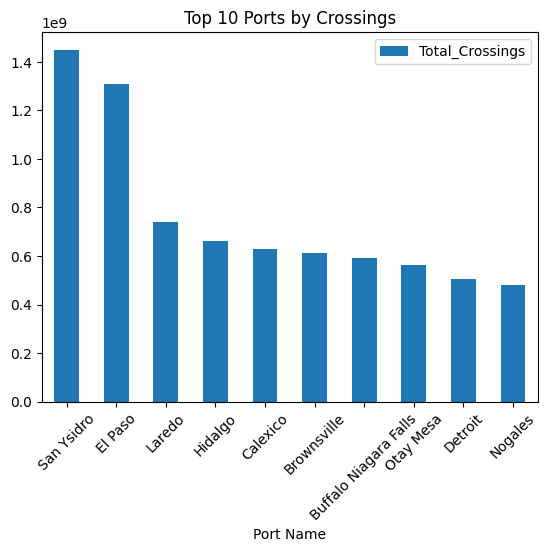

In [35]:
pdf = port_analysis.limit(10).toPandas()

pdf.plot(kind="bar", x="Port Name", y="Total_Crossings")
plt.title("Top 10 Ports by Crossings")
plt.xticks(rotation=45)
plt.show()

## 6. Equivalent Analysis with Spark SQL

This section demonstrates the use of Spark SQL to perform equivalent analyses, highlighting the flexibility of Spark’s unified processing engine.

#### Step 1: Register DataFrame as SQL View

The cleaned dataset is registered as a temporary view named "border_data". 
This enables the use of Spark SQL for querying and analysis.


In [36]:
df_clean.createOrReplaceTempView("border_data")

### 6.1 Total Crossings by Border
This query calculates total border crossings for each border.

The results show that the U.S.-Mexico border generally has higher traffic than the U.S.-Canada border, indicating stronger movement of people and goods.

In [37]:
result_border = spark.sql("""
SELECT Border, SUM(Value) AS Total
FROM border_data
GROUP BY Border
""")

result_border.show()

+----------------+----------+
|          Border|     Total|
+----------------+----------+
|US-Mexico Border|8596716289|
|US-Canada Border|2880226960|
+----------------+----------+



### 6.2 Total Crossings by Measure
This analysis shows the contribution of different transportation measures.

Personal vehicles and trucks contribute the most, highlighting their importance in cross-border transportation.

In [38]:
result_measure = spark.sql("""
SELECT Measure, SUM(Value) AS Total
FROM border_data
GROUP BY Measure
ORDER BY Total DESC
""")

result_measure.show()

+--------------------+----------+
|             Measure|     Total|
+--------------------+----------+
|Personal Vehicle ...|6506215972|
|   Personal Vehicles|3148059957|
|         Pedestrians|1303898913|
|              Trucks| 340546108|
|      Bus Passengers| 160027594|
|               Buses|   9545006|
|    Train Passengers|   7529303|
|              Trains|   1120396|
+--------------------+----------+



### 6.3 Total Crossings by Year
This analysis shows the trend of total border crossings over time.

Crossings increased in the late 1990s, declined after 2000, and gradually recovered after 2012.

In [39]:
result_year = spark.sql("""
SELECT Year, SUM(Value) AS Total
FROM border_data
GROUP BY Year
ORDER BY Year
""")

result_year.show()

+----+---------+
|Year|    Total|
+----+---------+
|1996|424326538|
|1997|487571047|
|1998|498367381|
|1999|526057768|
|2000|527422164|
|2001|479842216|
|2002|462021027|
|2003|443017400|
|2004|444305796|
|2005|436112146|
|2006|426158914|
|2007|403615100|
|2008|386600603|
|2009|348090864|
|2010|331717926|
|2011|319518381|
|2012|331070167|
|2013|342606811|
|2014|349085046|
|2015|350542766|
+----+---------+
only showing top 20 rows


### 6.4 Top Ports by Total Crossings
This analysis identifies the busiest ports.

San Ysidro and El Paso have the highest crossing volumes.

In [40]:
result_ports = spark.sql("""
SELECT `Port Name`, SUM(Value) AS Total
FROM border_data
GROUP BY `Port Name`
ORDER BY Total DESC
LIMIT 10
""")

result_ports.show()

+--------------------+----------+
|           Port Name|     Total|
+--------------------+----------+
|          San Ysidro|1449798032|
|             El Paso|1308744295|
|              Laredo| 741498521|
|             Hidalgo| 660325848|
|            Calexico| 630228448|
|         Brownsville| 612299728|
|Buffalo Niagara F...| 592241423|
|           Otay Mesa| 562269475|
|             Detroit| 506840195|
|             Nogales| 481449582|
+--------------------+----------+



## 7. MongoDB Aggregation Queries

In this section, we perform similar aggregations using MongoDB’s aggregation framework to compare with Spark-based processing.

### 7.1 Total Crossings by Border
This aggregation calculates total crossings for each border.

The U.S.-Mexico border shows significantly higher traffic than the U.S.-Canada border.

In [41]:
pipeline = [
    {
        "$group": {
            "_id": "$Border",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"total": -1}
    }
]

result_7_1 = list(collection.aggregate(pipeline))
result_7_1

[{'_id': 'US-Mexico Border', 'total': 8596716289},
 {'_id': 'US-Canada Border', 'total': 2880226960}]

### 7.2 Total Crossings by Measure
This analysis shows the contribution of different transportation measures.

Personal vehicles and trucks contribute the most to total crossings.

In [42]:
pipeline = [
    {
        "$group": {
            "_id": "$Measure",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"total": -1}
    }
]

result_7_2 = list(collection.aggregate(pipeline))
result_7_2

[{'_id': 'Personal Vehicle Passengers', 'total': 6506215972},
 {'_id': 'Personal Vehicles', 'total': 3148059957},
 {'_id': 'Pedestrians', 'total': 1303898913},
 {'_id': 'Trucks', 'total': 340546108},
 {'_id': 'Bus Passengers', 'total': 160027594},
 {'_id': 'Buses', 'total': 9545006},
 {'_id': 'Train Passengers', 'total': 7529303},
 {'_id': 'Trains', 'total': 1120396}]

### 7.3 Total Crossings by Year
This aggregation analyzes border crossings over time.

A significant drop can be observed around 2020 due to COVID-19, followed by recovery.

In [43]:
pipeline = [
    {
        "$addFields": {
            "Year": {
                "$toInt": {"$substr": ["$Date", 4, 4]}
            }
        }
    },
    {
        "$group": {
            "_id": "$Year",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"_id": 1}
    }
]

result_7_3 = list(collection.aggregate(pipeline))
result_7_3

[{'_id': 1996, 'total': 424326538},
 {'_id': 1997, 'total': 487571047},
 {'_id': 1998, 'total': 498367381},
 {'_id': 1999, 'total': 526057768},
 {'_id': 2000, 'total': 527422164},
 {'_id': 2001, 'total': 479842216},
 {'_id': 2002, 'total': 462021027},
 {'_id': 2003, 'total': 443017400},
 {'_id': 2004, 'total': 444305796},
 {'_id': 2005, 'total': 436112146},
 {'_id': 2006, 'total': 426158914},
 {'_id': 2007, 'total': 403615100},
 {'_id': 2008, 'total': 386600603},
 {'_id': 2009, 'total': 348090864},
 {'_id': 2010, 'total': 331717926},
 {'_id': 2011, 'total': 319518381},
 {'_id': 2012, 'total': 331070167},
 {'_id': 2013, 'total': 342606811},
 {'_id': 2014, 'total': 349085046},
 {'_id': 2015, 'total': 350542766},
 {'_id': 2016, 'total': 352587832},
 {'_id': 2017, 'total': 356675656},
 {'_id': 2018, 'total': 363185285},
 {'_id': 2019, 'total': 354128366},
 {'_id': 2020, 'total': 185454385},
 {'_id': 2021, 'total': 208001496},
 {'_id': 2022, 'total': 294204095},
 {'_id': 2023, 'total': 3286

7.4 Top Ports by Total Crossings
This query identifies the busiest ports.

Ports such as Laredo and Hidalgo rank among the top.

In [44]:
pipeline = [
    {
        "$group": {
            "_id": "$Port Name",
            "total": {"$sum": "$Value"}
        }
    },
    {
        "$sort": {"total": -1}
    },
    {
        "$limit": 10
    }
]

result_7_4 = list(collection.aggregate(pipeline))
result_7_4

[{'_id': 'San Ysidro', 'total': 1449798032},
 {'_id': 'El Paso', 'total': 1308744295},
 {'_id': 'Laredo', 'total': 741498521},
 {'_id': 'Hidalgo', 'total': 660325848},
 {'_id': 'Calexico', 'total': 630228448},
 {'_id': 'Brownsville', 'total': 612299728},
 {'_id': 'Buffalo Niagara Falls', 'total': 592241423},
 {'_id': 'Otay Mesa', 'total': 562269475},
 {'_id': 'Detroit', 'total': 506840195},
 {'_id': 'Nogales', 'total': 481449582}]

## 8. Performance Comparison and Optimization

This section evaluates query performance across different approaches, including PySpark DataFrame API, Spark SQL, and MongoDB aggregation.

We also demonstrate optimization techniques such as:
- Spark caching
- Query execution plan analysis
- MongoDB indexing

### 8.1 Performance Comparison

In this section, we compare the execution time of the same aggregation task across three different approaches:
- PySpark DataFrame API
- Spark SQL
- MongoDB aggregation

The goal is to evaluate how different processing engines handle the same workload and to identify which method is more efficient for this type of grouped query.

In [45]:
import time

print("=== Performance Comparison ===")

# Spark DataFrame API
start = time.time()

df_clean.groupBy("Year").agg(F.sum("Value").alias("Total_Crossings")).collect()

end = time.time()
spark_df_time = end - start
print("Spark DataFrame Time:", spark_df_time)

# Spark SQL
start = time.time()

spark.sql("""
SELECT Year, SUM(Value) AS Total_Crossings
FROM border_data
GROUP BY Year
""").collect()

end = time.time()
spark_sql_time = end - start
print("Spark SQL Time:", spark_sql_time)

# MongoDB Aggregation
start = time.time()

list(collection.aggregate([
    {"$group": {"_id": "$Year", "Total_Crossings": {"$sum": "$Value"}}}
]))

end = time.time()
mongo_time = end - start
print("MongoDB Aggregation Time:", mongo_time)

=== Performance Comparison ===
Spark DataFrame Time: 0.28957366943359375
Spark SQL Time: 0.2271578311920166
MongoDB Aggregation Time: 0.11362504959106445


### 8.2 Spark Optimization

To improve Spark performance, caching is applied to the cleaned DataFrame.  
Caching stores the dataset in memory so that repeated operations can avoid recomputation and repeated disk access.

We compare query execution time before and after caching, and then inspect the Spark execution plan.

In [46]:
# Remove any previous cache to ensure a fair comparison
df_clean.unpersist()

DataFrame[Port Name: string, State: string, Border: string, Date: date, Measure: string, Value: int, Year: int, Month: int]

In [47]:
print("=== Spark Optimization with Caching ===")

start = time.time()

df_clean.groupBy("Year").agg(F.sum("Value").alias("Total_Crossings")).collect()

end = time.time()
before_cache_time = end - start
print("Before Caching Time:", before_cache_time)

=== Spark Optimization with Caching ===
Before Caching Time: 0.24103331565856934


In [48]:
# Cache the DataFrame and materialize it
df_clean.cache()
df_clean.count()

273391

In [49]:
start = time.time()

df_clean.groupBy("Year").agg(F.sum("Value").alias("Total_Crossings")).collect()

end = time.time()
after_cache_time = end - start
print("After Caching Time:", after_cache_time)

After Caching Time: 0.30709338188171387


In [50]:
print("\n=== Spark Execution Plan ===")
df_clean.groupBy("Year").agg(F.sum("Value").alias("Total_Crossings")).explain()


=== Spark Execution Plan ===
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[Year#862], functions=[sum(Value#23)])
   +- Exchange hashpartitioning(Year#862, 200), ENSURE_REQUIREMENTS, [plan_id=1279]
      +- HashAggregate(keys=[Year#862], functions=[partial_sum(Value#23)])
         +- InMemoryTableScan [Value#23, Year#862]
               +- InMemoryRelation [Port Name#17, State#18, Border#20, Date#855, Measure#22, Value#23, Year#862, Month#863], StorageLevel(disk, memory, deserialized, 1 replicas)
                     +- *(1) Project [Port Name#17, State#18, Border#20, Date#855, Measure#22, Value#23, year(Date#855) AS Year#862, month(Date#855) AS Month#863]
                        +- *(1) Project [Port Name#17, State#18, Border#20, cast(gettimestamp(concat(01 , trim(Date#21, None)), dd MMM yyyy, TimestampType, try_to_date, Some(Europe/Helsinki), true) as date) AS Date#855, Measure#22, Value#23]
                           +- *(1) Filter atleastnnonnulls(1

**Explanation:**  
Caching can improve Spark performance when the same DataFrame is reused multiple times.  
After caching, Spark can read the data from memory instead of recomputing the full transformation pipeline or reloading data from disk.

The execution plan helps verify whether Spark is using cached data.  
If the plan includes terms such as `InMemoryTableScan` or `InMemoryRelation`, it indicates that caching is being used effectively.

**Conclusion:**  
The cached query is expected to be faster than the uncached query, especially when the dataset is reused repeatedly.  
If the improvement is small, this may be because the dataset is relatively small and the overhead of Spark job scheduling is already low.

Therefore, caching is most beneficial in workloads involving repeated analysis on the same processed dataset.

### 8.3 MongoDB Optimization

MongoDB performance can be improved by creating indexes on frequently queried fields.  
Here, an index is created on the `Year` field to evaluate whether it improves aggregation performance.

Although indexing is especially useful for filtering and sorting, it can also contribute to better query efficiency depending on the aggregation pipeline and dataset structure.

In [51]:
print("=== MongoDB Optimization with Indexing ===")

# Create index on Year
collection.create_index("Year")
print("Index created on 'Year'")

=== MongoDB Optimization with Indexing ===
Index created on 'Year'


In [52]:
start = time.time()

list(collection.aggregate([
    {"$group": {"_id": "$Year", "Total_Crossings": {"$sum": "$Value"}}}
]))

end = time.time()
mongo_indexed_time = end - start
print("MongoDB Indexed Time:", mongo_indexed_time)

MongoDB Indexed Time: 0.15159010887145996


**Explanation:**  
Indexing improves query performance by allowing MongoDB to locate relevant records more efficiently.  
In this project, an index was created on the `Year` field because it is used in grouping and analytical queries.

For simple aggregation queries without filtering, the impact of indexing may be limited.  
However, indexing becomes much more valuable in larger datasets and in queries involving filtering, sorting, or repeated access to specific fields.

**Overall Comparison:**  

The results show that Spark performs efficiently for repeated analytical queries, especially when caching is applied.  

MongoDB provides flexible querying and benefits from indexing, although its performance improvement is more noticeable in filtering operations than in simple aggregation.  

Overall, Spark is more suitable for iterative data analysis, while MongoDB is effective for structured data storage and retrieval.

## 9. Advanced Meaningful Analyses

Each member is responsible for one analysis question.

For each subsection:
- Clearly answer the question
- Include at least one visualization
- Provide a short interpretation of the results
- Write the final dataset back to MongoDB

You are encouraged to explore beyond the minimum requirements if you find interesting patterns.

### 9.1 Long-term Changes in Border Crossing Structure

Question:
How have transportation patterns changed over time at the U.S.-Canada and U.S.-Mexico borders?

Approach: To analyze long-term trends, the data is aggregated into 5-year intervals to reduce short-term fluctuations.  
Instead of focusing only on total crossings, this analysis examines the proportion of transportation modes within each border.
Additionally, a data-driven approach is used to identify the transportation modes with the largest proportional changes over time, ensuring that the analysis focuses on the most dynamic aspects of border crossing behavior.

In [53]:
from pyspark.sql.functions import floor

df_5year = df_clean.withColumn(
    "YearGroup",
    (floor(df_clean["Year"] / 5) * 5)
)

In [54]:
df_trend = df_5year.groupBy("YearGroup", "Border", "Measure") \
    .agg(F.sum("Value").alias("Total")) \
    .orderBy("YearGroup")

In [56]:
from pyspark.sql import Window

window_spec = Window.partitionBy("YearGroup", "Border")

df_ratio = df_trend.withColumn(
    "Total_Per_Group",
    F.sum("Total").over(window_spec)
).withColumn(
    "Ratio",
    F.col("Total") / F.col("Total_Per_Group")
)

In [57]:
df_variation = df_ratio.groupBy("Border", "Measure") \
    .agg(
        (F.max("Ratio") - F.min("Ratio")).alias("Variation")
    )

window_spec = Window.partitionBy("Border").orderBy(F.desc("Variation"))

df_ranked = df_variation.withColumn(
    "Rank",
    F.row_number().over(window_spec)
)

In [58]:
df_top3 = df_ranked.filter(F.col("Rank") <= 3)

df_top3.show(truncate=False)

+----------------+---------------------------+--------------------+----+
|Border          |Measure                    |Variation           |Rank|
+----------------+---------------------------+--------------------+----+
|US-Canada Border|Personal Vehicle Passengers|0.09013963400555258 |1   |
|US-Canada Border|Trucks                     |0.07684176785749863 |2   |
|US-Canada Border|Personal Vehicles          |0.04786874747252101 |3   |
|US-Mexico Border|Personal Vehicle Passengers|0.1127777200892266  |1   |
|US-Mexico Border|Personal Vehicles          |0.0661626436494882  |2   |
|US-Mexico Border|Pedestrians                |0.048983591893241446|3   |
+----------------+---------------------------+--------------------+----+



In [59]:
# South（US-Mexico）
south_measures = [
    row["Measure"] for row in df_top3
    .filter(df_top3["Border"] == "US-Mexico Border")
    .collect()
]

# North（US-Canada）
north_measures = [
    row["Measure"] for row in df_top3
    .filter(df_top3["Border"] == "US-Canada Border")
    .collect()
]

print("South top measures:", south_measures)
print("North top measures:", north_measures)

South top measures: ['Personal Vehicle Passengers', 'Personal Vehicles', 'Pedestrians']
North top measures: ['Personal Vehicle Passengers', 'Trucks', 'Personal Vehicles']


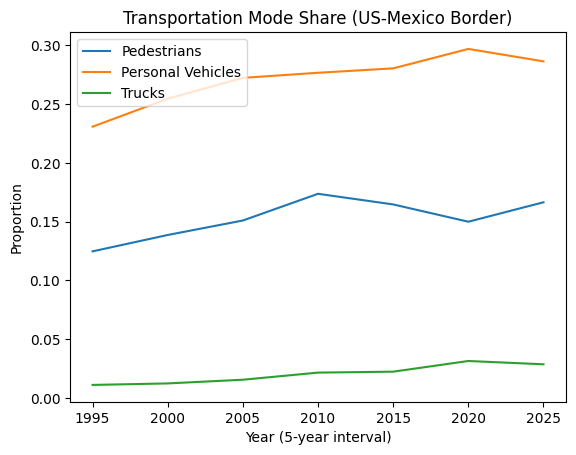

In [62]:
import matplotlib.pyplot as plt

df_ratio_pd = df_ratio.toPandas()

selected_measures = ["Personal Vehicles", "Pedestrians", "Trucks"]

south = df_ratio_pd[
    (df_ratio_pd["Border"] == "US-Mexico Border") &
    (df_ratio_pd["Measure"].isin(selected_measures))
]

df_south = south.groupby(["YearGroup", "Measure"])["Ratio"].sum().reset_index()

plt.figure()

for measure in df_south["Measure"].unique():
    subset = df_south[df_south["Measure"] == measure]
    plt.plot(subset["YearGroup"], subset["Ratio"], label=measure)

plt.xlabel("Year (5-year interval)")
plt.ylabel("Proportion")
plt.title("Transportation Mode Share (US-Mexico Border)")
plt.legend()
plt.show()

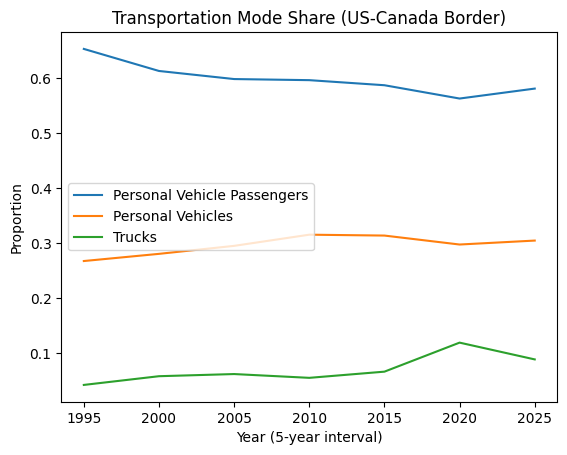

In [63]:
north = df_ratio_pd[
    (df_ratio_pd["Border"] == "US-Canada Border") &
    (df_ratio_pd["Measure"].isin(north_measures))
]

df_north = north.groupby(["YearGroup", "Measure"])["Ratio"].sum().reset_index()

plt.figure()

for measure in df_north["Measure"].unique():
    subset = df_north[df_north["Measure"] == measure]
    plt.plot(subset["YearGroup"], subset["Ratio"], label=measure)

plt.xlabel("Year (5-year interval)")
plt.ylabel("Proportion")
plt.title("Transportation Mode Share (US-Canada Border)")
plt.legend()
plt.show()

**Interpretation:**  

The transportation patterns at both borders show distinct trends over time.

At the U.S.-Mexico border, the proportion of personal vehicle passengers has steadily decreased from around 63% to about 51%, indicating a shift away from passenger-based car travel. In contrast, personal vehicle crossings have gradually increased, suggesting a rise in individual vehicle usage. Pedestrian crossings also show a moderate upward trend, reflecting growing short-distance or daily cross-border movement.

At the U.S.-Canada border, the structure is more stable. Personal vehicle passengers remain the dominant mode, although their proportion has slightly declined over time. Personal vehicle crossings have increased gradually, while truck crossings show a noticeable spike around 2020, likely reflecting changes in trade activity.

Overall, the U.S.-Mexico border exhibits more dynamic structural changes, while the U.S.-Canada border remains relatively stable with gradual shifts in transportation modes.

In [64]:
# Write final dataset back to MongoDB

df_output = df_ratio.toPandas()

collection_9_1 = db["analysis_9_1"]

collection_9_1.delete_many({})  # clear old data
collection_9_1.insert_many(df_output.to_dict("records"))

print("9.1 results written to MongoDB")

9.1 results written to MongoDB


### 9.2 Peak Month and Peak Volume for Top Ports

Question:
For the top ports at each border, which month has the highest crossing volume?

(Hint: identify both the peak month and the corresponding volume, and compare patterns across ports.)

### Data Preparation

In [ ]:
import pyspark.sql.functions as F

df_92 = df.select(
    "Port Name",
    "State",
    "Border",
    "Date",
    "Measure",
    "Value"
).dropna()

df_92 = df_92.withColumn(
    "Date",
    F.to_date(
        F.concat(F.lit("01 "), F.trim(F.col("Date"))),
        "dd MMM yyyy"
    )
)

df_92 = df_92.withColumn("Year", F.year(F.col("Date")))
df_92 = df_92.withColumn("Month", F.month(F.col("Date")))

df_92.select("Date", "Year", "Month").show(5)

+----------+----+-----+
|      Date|Year|Month|
+----------+----+-----+
|2026-01-01|2026|    1|
|2026-01-01|2026|    1|
|2025-12-01|2025|   12|
|2025-11-01|2025|   11|
|2025-07-01|2025|    7|
+----------+----+-----+
only showing top 5 rows


In [ ]:
import pyspark.sql.functions as F
from pyspark.sql.window import Window

### Identify Top Ports by Border

In [ ]:
port_totals = df_92.groupBy("Border", "Port Name") \
    .agg(F.sum("Value").alias("Total_Crossings"))

port_totals.orderBy("Border", F.col("Total_Crossings").desc()).show(10)

+----------------+--------------------+---------------+
|          Border|           Port Name|Total_Crossings|
+----------------+--------------------+---------------+
|US-Canada Border|Buffalo Niagara F...|      592241423|
|US-Canada Border|             Detroit|      506840195|
|US-Canada Border|              Blaine|      321701080|
|US-Canada Border|          Port Huron|      182957204|
|US-Canada Border|Champlain Rouses ...|      120446282|
|US-Canada Border|  Sault Sainte Marie|       87201484|
|US-Canada Border|             Massena|       86457287|
|US-Canada Border|              Calais|       83639381|
|US-Canada Border|               Sumas|       74730325|
|US-Canada Border|       Point Roberts|       67311621|
+----------------+--------------------+---------------+
only showing top 10 rows


In [ ]:
port_window = Window.partitionBy("Border").orderBy(F.col("Total_Crossings").desc())

ranked_ports = port_totals.withColumn("Port_Rank", F.row_number().over(port_window))

ranked_ports.show(10)

+----------------+--------------------+---------------+---------+
|          Border|           Port Name|Total_Crossings|Port_Rank|
+----------------+--------------------+---------------+---------+
|US-Canada Border|Buffalo Niagara F...|      592241423|        1|
|US-Canada Border|             Detroit|      506840195|        2|
|US-Canada Border|              Blaine|      321701080|        3|
|US-Canada Border|          Port Huron|      182957204|        4|
|US-Canada Border|Champlain Rouses ...|      120446282|        5|
|US-Canada Border|  Sault Sainte Marie|       87201484|        6|
|US-Canada Border|             Massena|       86457287|        7|
|US-Canada Border|              Calais|       83639381|        8|
|US-Canada Border|               Sumas|       74730325|        9|
|US-Canada Border|       Point Roberts|       67311621|       10|
+----------------+--------------------+---------------+---------+
only showing top 10 rows


In [ ]:
top_ports = ranked_ports.filter(F.col("Port_Rank") <= 3)

top_ports.orderBy("Border", "Port_Rank").show()

+----------------+--------------------+---------------+---------+
|          Border|           Port Name|Total_Crossings|Port_Rank|
+----------------+--------------------+---------------+---------+
|US-Canada Border|Buffalo Niagara F...|      592241423|        1|
|US-Canada Border|             Detroit|      506840195|        2|
|US-Canada Border|              Blaine|      321701080|        3|
|US-Mexico Border|          San Ysidro|     1449798032|        1|
|US-Mexico Border|             El Paso|     1308744295|        2|
|US-Mexico Border|              Laredo|      741498521|        3|
+----------------+--------------------+---------------+---------+



In [ ]:
df_top_ports = df_92.join(
    top_ports.select("Border", "Port Name"),
    on=["Border", "Port Name"],
    how="inner"
)

df_top_ports.show(5)

+----------------+---------+----------+----------+-------+------+----+-----+
|          Border|Port Name|     State|      Date|Measure| Value|Year|Month|
+----------------+---------+----------+----------+-------+------+----+-----+
|US-Mexico Border|   Laredo|     Texas|2025-07-01|  Buses|  2546|2025|    7|
|US-Mexico Border|   Laredo|     Texas|2025-02-01| Trains|   304|2025|    2|
|US-Canada Border|   Blaine|Washington|2024-06-01|  Buses|   803|2024|    6|
|US-Canada Border|   Blaine|Washington|2024-04-01| Trains|   184|2024|    4|
|US-Mexico Border|   Laredo|     Texas|2024-02-01| Trucks|251110|2024|    2|
+----------------+---------+----------+----------+-------+------+----+-----+
only showing top 5 rows


### Monthly Crossing Totals

In [ ]:
monthly_totals = df_top_ports.groupBy("Border", "Port Name", "Month") \
    .agg(F.sum("Value").alias("Monthly_Total"))

monthly_totals.orderBy("Border", "Port Name", "Month").show(20)

+----------------+--------------------+-----+-------------+
|          Border|           Port Name|Month|Monthly_Total|
+----------------+--------------------+-----+-------------+
|US-Canada Border|              Blaine|    1|     22727808|
|US-Canada Border|              Blaine|    2|     22597469|
|US-Canada Border|              Blaine|    3|     26099066|
|US-Canada Border|              Blaine|    4|     25675919|
|US-Canada Border|              Blaine|    5|     27560255|
|US-Canada Border|              Blaine|    6|     28262011|
|US-Canada Border|              Blaine|    7|     32741162|
|US-Canada Border|              Blaine|    8|     34648694|
|US-Canada Border|              Blaine|    9|     27871670|
|US-Canada Border|              Blaine|   10|     25276728|
|US-Canada Border|              Blaine|   11|     23708142|
|US-Canada Border|              Blaine|   12|     24532156|
|US-Canada Border|Buffalo Niagara F...|    1|     34849514|
|US-Canada Border|Buffalo Niagara F...| 

### Peak Month and Peak Volume

In [ ]:
from pyspark.sql.window import Window

peak_window = Window.partitionBy("Border", "Port Name").orderBy(F.col("Monthly_Total").desc())

peak_months = monthly_totals.withColumn("Month_Rank", F.row_number().over(peak_window)) \
    .filter(F.col("Month_Rank") == 1) \
    .select("Border", "Port Name", "Month", "Monthly_Total") \
    .orderBy("Border", "Port Name")

peak_months.show()

+----------------+--------------------+-----+-------------+
|          Border|           Port Name|Month|Monthly_Total|
+----------------+--------------------+-----+-------------+
|US-Canada Border|              Blaine|    8|     34648694|
|US-Canada Border|Buffalo Niagara F...|    8|     75840458|
|US-Canada Border|             Detroit|    8|     47881835|
|US-Mexico Border|             El Paso|   12|    113378398|
|US-Mexico Border|              Laredo|   12|     67677905|
|US-Mexico Border|          San Ysidro|    8|    128982124|
+----------------+--------------------+-----+-------------+



### Visualization

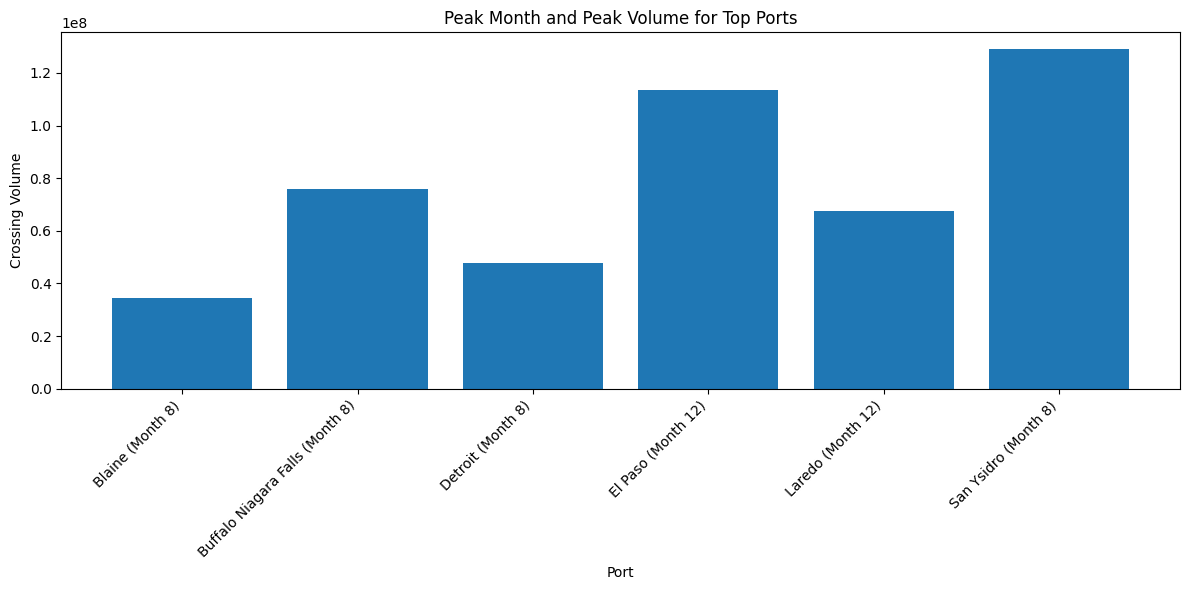

In [ ]:
import matplotlib.pyplot as plt

peak_pd = peak_months.toPandas()

labels = peak_pd["Port Name"] + " (Month " + peak_pd["Month"].astype(str) + ")"

plt.figure(figsize=(12, 6))
plt.bar(labels, peak_pd["Monthly_Total"])
plt.xticks(rotation=45, ha="right")
plt.title("Peak Month and Peak Volume for Top Ports")
plt.xlabel("Port")
plt.ylabel("Crossing Volume")
plt.tight_layout()
plt.show()

### Interpretation

The analysis shows that peak crossing months vary across major ports. Several U.S.-Canada border ports reach peak activity in August, while key U.S.-Mexico ports such as Laredo and El Paso peak in December. This indicates that seasonal patterns differ depending on the border and location.

### Save Results to MongoDB

In [ ]:
peak_pd_records = peak_months.toPandas().to_dict("records")

collection_92 = db["analysis_9_2_peak_months"]
collection_92.delete_many({})
collection_92.insert_many(peak_pd_records)

print("9.2 results written to MongoDB")

9.2 results written to MongoDB


### 9.3 Impact of External Events (COVID-19)

Question:
How did COVID-19 affect border crossing volumes over time?

(Hint: compare trends before, during, and after the pandemic, and look for disruptions and recovery patterns.)

In [65]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "Period",
    when(col("Year") < 2020, "Before COVID")
    .when((col("Year") >= 2020) & (col("Year") <= 2021), "During COVID")
    .otherwise("After COVID")
)

In [66]:
from pyspark.sql.functions import sum

covid_analysis = df.groupBy("Period") \
    .agg(sum("Value").alias("Total_Crossings")) \
    .orderBy("Period")

covid_analysis.show()

+------------+---------------+
|      Period|Total_Crossings|
+------------+---------------+
| After COVID|     1338860168|
|Before COVID|     9744627200|
|During COVID|      393455881|
+------------+---------------+



In [67]:
spark.sql("""
SELECT
  CASE
    WHEN YEAR(to_date(Date, 'MMM yyyy')) < 2020 THEN 'Before COVID'
    WHEN YEAR(to_date(Date, 'MMM yyyy')) BETWEEN 2020 AND 2021 THEN 'During COVID'
    ELSE 'After COVID'
  END AS Period,
  SUM(Value) AS Total_Crossings
FROM crossings
GROUP BY
  CASE
    WHEN YEAR(to_date(Date, 'MMM yyyy')) < 2020 THEN 'Before COVID'
    WHEN YEAR(to_date(Date, 'MMM yyyy')) BETWEEN 2020 AND 2021 THEN 'During COVID'
    ELSE 'After COVID'
  END
ORDER BY Period
""").show()

+------------+---------------+
|      Period|Total_Crossings|
+------------+---------------+
| After COVID|     1338860168|
|Before COVID|     9744627200|
|During COVID|      393455881|
+------------+---------------+



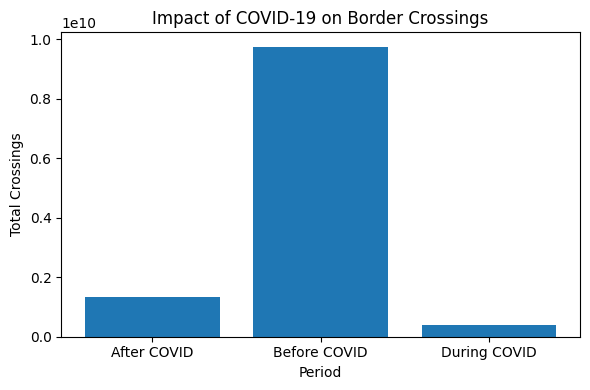

In [68]:
import matplotlib.pyplot as plt

pdf = covid_analysis.toPandas()

plt.figure(figsize=(6,4))
plt.bar(pdf["Period"], pdf["Total_Crossings"])

plt.title("Impact of COVID-19 on Border Crossings")
plt.xlabel("Period")
plt.ylabel("Total Crossings")

plt.tight_layout()
plt.show()

### 9.4 Port Growth & Decline Analysis

Question:
Which ports have experienced the most significant growth or decline over time?

(Hint: compare two time points and consider both absolute and relative changes.)

#### Step 1：Choose 2019 vs 2024
This pipeline extracts yearly data and compares port activity between two selected years.

In [69]:
pipeline = [
    {
        "$addFields": {
            "Year": {
                "$toInt": {"$substr": ["$Date", 4, 4]}
            }
        }
    },
    {
        "$match": {
            "Year": {"$in": [2019, 2024]}
        }
    },
    {
        "$group": {
            "_id": {
                "Port": "$Port Name",
                "Year": "$Year"
            },
            "total": {"$sum": "$Value"}
        }
    }
]

data = list(collection.aggregate(pipeline))

#### Step 2：Convert to Pandas DataFrame
The data is converted to a Pandas DataFrame for further analysis.

In [70]:
import pandas as pd  

df_growth = pd.DataFrame(data)  

# Extract fields from nested structure
df_growth["Port"] = df_growth["_id"].apply(lambda x: x["Port"])  
df_growth["Year"] = df_growth["_id"].apply(lambda x: x["Year"])  

# Pivot table for comparison
df_pivot = df_growth.pivot(index="Port", columns="Year", values="total").fillna(0)  

# Calculate change between years
df_pivot["Change"] = df_pivot[2024] - df_pivot[2019]  

# Sort by change
df_sorted = df_pivot.sort_values("Change", ascending=False)  

df_sorted.head(10)

Year,2019,2024,Change
Port,,,
Ysleta,0.0,12100990.0,12100990.0
Hidalgo,15553020.0,18134636.0,2581616.0
San Luis,10469779.0,11570188.0,1100409.0
Tornillo,1361577.0,2317675.0,956098.0
Nogales,14125594.0,15007703.0,882109.0
Cross Border Xpress,1620661.0,2175047.0,554386.0
Progreso,5174707.0,5688000.0,513293.0
Eagle Pass,9951845.0,10414971.0,463126.0
Santa Teresa,2304052.0,2730006.0,425954.0


### Top 10 Ports by Growth (2019–2024)

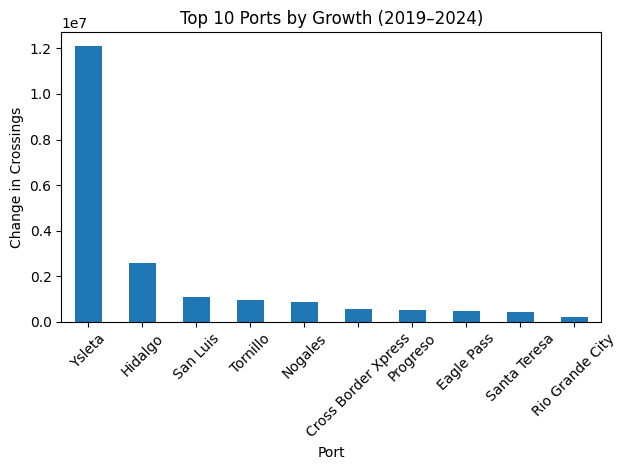

In [71]:
import matplotlib.pyplot as plt

# Select top 10 growth ports
top_growth = df_sorted.head(10)

plt.figure()
top_growth["Change"].plot(kind="bar")

plt.title("Top 10 Ports by Growth (2019–2024)")
plt.xlabel("Port")
plt.ylabel("Change in Crossings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the ports with the highest growth between 2019 and 2024.

### Top 10 Ports by Decline (2019–2024)

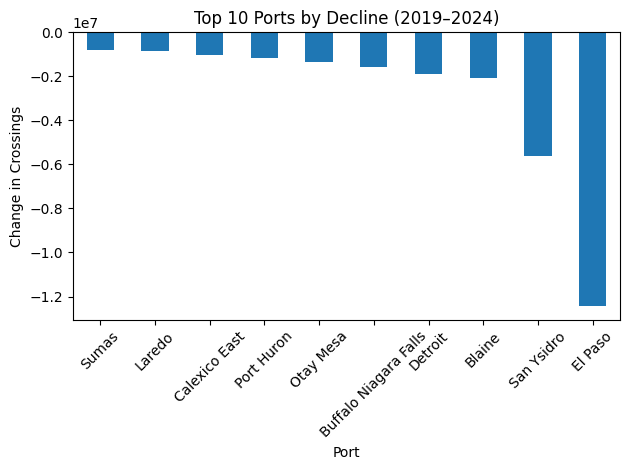

In [72]:
bottom_ports = df_sorted.tail(10)

plt.figure()
bottom_ports["Change"].plot(kind="bar")

plt.title("Top 10 Ports by Decline (2019–2024)")
plt.xlabel("Port")
plt.ylabel("Change in Crossings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The chart shows that some ports experienced significant growth, while others declined.

This reflects changes in cross-border traffic patterns over time.